In [162]:
# Import the libraries

%pip install yfinance 
%pip install plotly
%pip install scikit-learn
%pip install xgboost
%pip install matplotlib
%pip install seaborn

import yfinance as yf

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.graph_objects as go 
import plotly.express as px 
#import plotly.io as pio



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note

### Download the data from yfinanace

In [170]:
# Download the stock data from yfinance
import yfinance as yf
# Define the stock ticker and the date range
tickers = ['AAPL']
#tickers.append('GC=F')  # Gold futures
#tickers.append('BTC-USD')  # Bitcoin in USD
start_date = '2020-01-01'
end_date = '2026-01-01'

# Download the stock data
stocks = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)
gold = yf.download('GC=F', start=start_date, end=end_date, auto_adjust=True)
BTC = yf.download('BTC-USD', start=start_date, end=end_date, auto_adjust=True)
sp500 = yf.download('^GSPC', start=start_date, end=end_date, auto_adjust=True)
nasdaq = yf.download('^IXIC', start=start_date, end=end_date, auto_adjust=True)
dowjones = yf.download('^DJI', start=start_date, end=end_date, auto_adjust=True)   

# Arrange the data so that 'Close' price can directly be used for plotting and calculations
stocks.columns = stocks.columns.droplevel(1)  # Drop the ticker level from columns
gold.columns = gold.columns.droplevel(1)
BTC.columns = BTC.columns.droplevel(1)
sp500.columns = sp500.columns.droplevel(1)
nasdaq.columns = nasdaq.columns.droplevel(1)
dowjones.columns = dowjones.columns.droplevel(1)

# Add the major indices as features to the stocks DataFrame
stocks['sp500'] = sp500['Close']
stocks['nasdaq'] = nasdaq['Close']
stocks['dowjones'] = dowjones['Close']

# reset the index to make 'Date' a column
#stocks.reset_index(inplace=True)
# Drop the Open, High, Low columns
stocks.drop(columns=['Open', 'High', 'Low'], inplace=True)

stocks.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Close,Volume,sp500,nasdaq,dowjones
Date,,,,,
2020-01-02,72.400520,135480400,3257.850098,9092.190430,28868.800781
2020-01-03,71.696632,146322800,3234.850098,9020.769531,28634.880859
2020-01-06,72.267914,118387200,3246.280029,9071.469727,28703.380859
2020-01-07,71.928062,108872000,3237.179932,9068.580078,28583.679688
2020-01-08,73.085114,132079200,3253.050049,9129.240234,28745.089844


In [178]:
# Normalize the gold and bitcoin prices to the first value to compare relative changes
def normalize_to_first(df):
    return df / df.iloc[0]

stocks['Gold'] = normalize_to_first(gold['Close'])
stocks['Bitcoin'] = normalize_to_first(BTC['Close'])


# Add the target variable, the direction of the stock price movement the next day
stocks['Target'] = np.where(stocks['Close'].shift(-1) > stocks['Close'], 1, 0)

# Add a target variable which predicts that at the end of next 5 days the stock price will be higher than today
#stocks['Target'] = np.where(stocks['Close'].shift(-5) > stocks['Close'], 1, 0)

stocks.head(20)

Price,Close,Volume,sp500,nasdaq,dowjones,Gold,Bitcoin,Target,MA20,STD20,...,RSI,EMA12,EMA26,MACD,SignalLine,MACD_Histogram,DayOfWeek,Month,Quarter,RSI_bin
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,72.400520,135480400,3257.850098,9092.190430,28868.800781,1.000000,0.970181,0,NaN,NaN,...,NaN,72.400520,72.400520,0.000000,0.000000,0.000000,3,1,1,NaN
2020-01-03,71.696632,146322800,3234.850098,9020.769531,28634.880859,1.016202,1.020098,1,NaN,NaN,...,NaN,72.019248,72.035040,-0.015792,-0.008774,-0.007019,4,1,1,NaN
2020-01-06,72.267914,118387200,3246.280029,9071.469727,28703.380859,1.027353,1.079032,0,NaN,NaN,...,NaN,72.116302,72.118709,-0.002407,-0.006164,0.003757,0,1,1,NaN
2020-01-07,71.928062,108872000,3237.179932,9068.580078,28583.679688,1.031027,1.133819,1,NaN,NaN,...,NaN,72.056882,72.065413,-0.008531,-0.006966,-0.001565,1,1,1,NaN
2020-01-08,73.085114,132079200,3253.050049,9129.240234,28745.089844,1.021581,1.122176,1,NaN,NaN,...,NaN,72.336249,72.301886,0.034363,0.005329,0.029035,2,1,1,NaN
2020-01-09,74.637520,170108400,3274.699951,9203.429688,28956.900391,1.017842,1.094289,1,NaN,NaN,...,NaN,72.895579,72.769695,0.125884,0.038006,0.087878,3,1,1,NaN
2020-01-10,74.806252,140644800,3265.350098,9178.860352,28823.769531,1.021646,1.134216,1,NaN,NaN,...,NaN,73.321939,73.131886,0.190053,0.076485,0.113568,4,1,1,NaN
2020-01-13,76.404427,121532000,3288.129883,9273.929688,28907.050781,1.015677,1.131111,0,NaN,NaN,...,NaN,73.965206,73.659173,0.306033,0.131650,0.174384,0,1,1,NaN
2020-01-14,75.372681,161954400,3283.149902,9251.330078,28939.669922,1.011742,1.226049,0,NaN,NaN,...,NaN,74.243655,73.913152,0.330502,0.177586,0.152917,1,1,1,NaN


In [179]:
### Add Bollinger Bands to the stock data
# Calculate the 20-day moving average and standard deviation


def Bollinger_Bands(df, window=20, num_std_dev=2):
    df['MA20'] = df['Close'].rolling(window=window).mean()
    df['STD20'] = df['Close'].rolling(window=window).std()
    df['UpperBand'] = df['MA20'] + (df['STD20'] * num_std_dev)
    df['LowerBand'] = df['MA20'] - (df['STD20'] * num_std_dev)
    return df
stocks = Bollinger_Bands(stocks)  
#stocks.dropna(inplace=True)
#.reset_index(inplace=True)  # Drop rows with NaN values resulting from rolling calculations

stocks.head()

# Plot the stock price and Bollinger Bands
#pio.renderers.default = "browser"
def plot_bollinger_bands(stocks):
    fig = go.Figure().update_layout(width=1000, height=600, title='AAPL Stock Price with Bollinger Bands', xaxis_title='Date', yaxis_title='Price (USD)')
    fig.add_trace(go.Scatter(x=stocks.index, y=stocks['Close'], mode='lines', name='Close Price'))

    fig.add_trace(go.Scatter(x=stocks.index, 
                            y=stocks['UpperBand'], 
                            mode = 'lines', 
                            name='Upper Bollinger Band', 
                            line=dict(color='red', dash='dot')))

    fig.add_trace(go.Scatter(x=stocks.index, 
                            y=stocks['LowerBand'], 
                            mode = 'lines', 
                            name='Lower Bollinger Band', 
                            line=dict(color='red', dash='dot')))
    fig.show()
plot_bollinger_bands(stocks)


### Feature Engineering

In [180]:
print(stocks.index)

# Add a feature for return %
stocks['Return'] = stocks['Close'].pct_change()*100


# Add momentum and rate of change features
stocks['Momentum_5'] = stocks['Close'] - stocks['Close'].shift(5)
stocks['ROC_5'] = stocks['Close'].pct_change(5)*100

# Add return lags
def add_return_lags(df, lag_days=5):
    for lag in range(1, lag_days + 1):
        df[f'Return_Lag{lag}'] = df['Return'].shift(lag)
    return df
stocks = add_return_lags(stocks, lag_days=4)

# Get 5 day 20 day, 50 day, and 200 day moving averages for price
stocks['MA5'] = stocks['Close'].rolling(window=5).mean()
stocks['MA50'] = stocks['Close'].rolling(window=50).mean()
stocks['MA200'] = stocks['Close'].rolling(window=200).mean()

# Add a price vs moving average feature
stocks['Price_vs_MA20'] = stocks['Close']/stocks['MA5']

# Get the lag features for the closing price
def add_price_lags(df, lag_days=2):
    for lag in range(1, lag_days + 1):
        df[f'Lag{lag}'] = df['Close'].shift(lag)
    return df
stocks = add_price_lags(stocks, lag_days=6)

# Moving average of volume for last 5 days
stocks['Volume_MA5'] = stocks['Volume'].rolling(window=5).mean()

# Moving average of volume volatility for last 5 days
stocks['Volatility'] = stocks['Close'].rolling(window=5).std()

# Capture volume spikes
stocks['VolumeSpike'] = np.where(stocks['Volume'] > 
                                 (stocks['Volume'].rolling(window=20).mean() + 
                                  2*stocks['Volume'].rolling(window=20).std()), 1, 0)

print(stocks.index)

# Relative Strength Index (RSI)
def RSI(df, period=14):
    delta = df['Close'].diff()
    gains = delta.where(delta > 0, 0)
    losses = -delta.where(delta < 0, 0)
    avg_gains = gains.rolling(window=period).mean()
    avg_losses = losses.rolling(window=period).mean()
    rs = avg_gains/avg_losses
    #print(rs)
    df['RSI'] = 100 - (100/(1 + rs))
    return df

RSI(stocks, 14)

# MACD - Moving Average Convergence Divergence
def MACD(df, short_window=12, long_window=26, signal_window=9):
    df['EMA12'] = df['Close'].ewm(span=short_window).mean()
    df['EMA26'] = df['Close'].ewm(span=long_window).mean()
    df['MACD'] = df['EMA12'] - df['EMA26']
    df['SignalLine'] = df['MACD'].ewm(span=signal_window).mean()
    df['MACD_Histogram'] = df['MACD'] - df['SignalLine']
    return df

MACD(stocks)
###stocks.dropna(inplace=True)

# Add the seasonality features
stocks['DayOfWeek'] = stocks.index.dayofweek
stocks['Month'] = stocks.index.month
stocks['Quarter'] = stocks.index.quarter

stocks.head()


DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2025-12-17', '2025-12-18', '2025-12-19', '2025-12-22',
               '2025-12-23', '2025-12-24', '2025-12-26', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[s]', name='Date', length=1508, freq=None)
DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2025-12-17', '2025-12-18', '2025-12-19', '2025-12-22',
               '2025-12-23', '2025-12-24', '2025-12-26', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[s]', name='Date', length=1508, freq=None)


Price,Close,Volume,sp500,nasdaq,dowjones,Gold,Bitcoin,Target,MA20,STD20,...,RSI,EMA12,EMA26,MACD,SignalLine,MACD_Histogram,DayOfWeek,Month,Quarter,RSI_bin
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,72.400520,135480400,3257.850098,9092.190430,28868.800781,1.000000,0.970181,0,NaN,NaN,...,NaN,72.400520,72.400520,0.000000,0.000000,0.000000,3,1,1,NaN
2020-01-03,71.696632,146322800,3234.850098,9020.769531,28634.880859,1.016202,1.020098,1,NaN,NaN,...,NaN,72.019248,72.035040,-0.015792,-0.008774,-0.007019,4,1,1,NaN
2020-01-06,72.267914,118387200,3246.280029,9071.469727,28703.380859,1.027353,1.079032,0,NaN,NaN,...,NaN,72.116302,72.118709,-0.002407,-0.006164,0.003757,0,1,1,NaN
2020-01-07,71.928062,108872000,3237.179932,9068.580078,28583.679688,1.031027,1.133819,1,NaN,NaN,...,NaN,72.056882,72.065413,-0.008531,-0.006966,-0.001565,1,1,1,NaN
2020-01-08,73.085114,132079200,3253.050049,9129.240234,28745.089844,1.021581,1.122176,1,NaN,NaN,...,NaN,72.336249,72.301886,0.034363,0.005329,0.029035,2,1,1,NaN


In [174]:
print(stocks.index)
def plot_stock_feature(stocks, feature_name):
    fig = go.Figure().update_layout(width=1000, height=600, title=f'AAPL Stock {feature_name}', xaxis_title='Date', yaxis_title='Price (USD)')
    fig.add_trace(go.Scatter(x=stocks.index, y=stocks[feature_name], mode='lines', name=feature_name))
    fig.show()

def plot_overlay(stocks, feature1, feature2, feature3=None, feature4=None, title=None):
    fig = go.Figure().update_layout(width=1000, height=600, title=title or f'AAPL Stock {feature1} vs {feature2}', xaxis_title='Date', yaxis_title='Value')
    fig.add_trace(go.Scatter(x=stocks.index, y=stocks[feature1], mode='lines', name=feature1, line=dict(color='blue')))
    fig.add_trace(go.Scatter(x=stocks.index, y=stocks[feature2], mode='lines', name=feature2, line=dict(color='red')))
    if feature3 is not None:
        fig.add_trace(go.Scatter(x=stocks.index, y=stocks[feature3], mode='lines', name=feature3, line=dict(color='green')))
    if feature4 is not None:
        fig.add_trace(go.Scatter(x=stocks.index, y=stocks[feature4], mode='lines', name=feature4, line=dict(color='orange')))
    fig.show()

plot_stock_feature(stocks, 'Return')
#plot_stock_feature(stocks, 'Momentum_5')
plot_stock_feature(stocks, 'ROC_5')
plot_overlay(stocks, 'Close', 'MA5', 'MA50', 'MA200', title='AAPL Stock Price vs Momentum indicators')

#plot_overlay(stocks, 'Close', 'Return', 'Momentum_5', 'ROC_5', title='AAPL Stock Price vs Momentum indicators')

def plot_log_indicators(stocks):
    # Add log of momentum features
    stocks['LogReturn'] = np.log2(stocks['Return'] + 100)  # Shift to avoid log of negative numbers
    stocks['LogMomentum_5'] = np.log2(stocks['Momentum_5'] + 100)  # Shift to avoid log of negative numbers
    stocks['LogROC_5'] = np.log2(stocks['ROC_5'] + 100)  # Shift to avoid log of negative numbers
    stocks['LogClose'] = np.log2(stocks['Close'])  # Log of closing price for better visualization
    plot_overlay(stocks, 'LogClose', 'LogReturn', 'LogMomentum_5', 'LogROC_5', title='AAPL Stock Price vs Momentum indicators')



DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2025-12-17', '2025-12-18', '2025-12-19', '2025-12-22',
               '2025-12-23', '2025-12-24', '2025-12-26', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[s]', name='Date', length=1508, freq=None)


In [181]:
# More useful plot to understand the data
stocks.dropna()
stocks['RSI_bin'] = pd.cut(stocks['RSI'], bins=5, labels=False)
#stocks.groupby('RSI_bin')['Target'].mean()
stocks.head()

# Plot the Stock Return distribution
fig = px.histogram(stocks, x='Return', nbins=50, title='Distribution of AAPL Stock Returns', labels={'Return': 'Daily Return (%)'})
fig.update_layout(width=1000, height=600)  
fig.show()

# Target variable distribution
fig = px.histogram(stocks, x='Target', title='Distribution of Target Variable (Stock Direction)', labels={'Target': 'Stock Direction (0=Down, 1=Up)'})
fig.update_layout(width=1000, height=600)
fig.show()
stocks['Target'].value_counts(normalize=True)*100




Target
1    53.116711
0    46.883289
Name: proportion, dtype: float64

Correlation of features with Target variable:
Price
Target            1.000000
Quarter           0.033617
Month             0.030984
Gold              0.020668
MA200             0.019822
Bitcoin           0.014293
nasdaq            0.007471
Return_Lag1       0.006997
sp500             0.006534
Return_Lag2       0.000734
dowjones          0.000336
Volatility       -0.000481
STD20            -0.000846
RSI              -0.001718
Lag6             -0.001738
LowerBand        -0.001821
MA20             -0.001843
UpperBand        -0.001849
RSI_bin          -0.003016
Lag5             -0.003130
EMA26            -0.003875
VolumeSpike      -0.005110
DayOfWeek        -0.005256
EMA12            -0.005326
Lag4             -0.006412
Close            -0.006787
Lag2             -0.007084
MA5              -0.007113
Lag3             -0.008367
Lag1             -0.008473
Volume           -0.009803
MA50             -0.009807
Return_Lag3      -0.011395
MACD_Histogram   -0.014378
Price_vs_MA20    -0.018348
Vol

Correlation of features with Close price:
Price
Lag1              0.998186
MA5               0.997745
Lag2              0.996295
EMA12             0.995819
Lag3              0.994318
Lag4              0.992494
Lag5              0.990773
EMA26             0.990765
MA20              0.989879
Lag6              0.989112
UpperBand         0.986137
LowerBand         0.985871
MA50              0.973462
sp500             0.946350
dowjones          0.940469
nasdaq            0.908865
MA200             0.894527
Bitcoin           0.809349
Gold              0.799293
STD20             0.375164
Month             0.256111
Quarter           0.253915
SignalLine        0.249777
MACD              0.236431
Volatility        0.210680
Momentum_5        0.083628
RSI               0.060298
RSI_bin           0.060240
VolumeSpike       0.035551
ROC_5             0.028945
Price_vs_MA20     0.027966
Return_Lag2       0.011272
Return            0.010645
Return_Lag1       0.009613
Return_Lag3       0.009043
MACD_Hi

<Axes: title={'center': 'Correlation of Lag Features with Target Variable'}, ylabel='Price'>

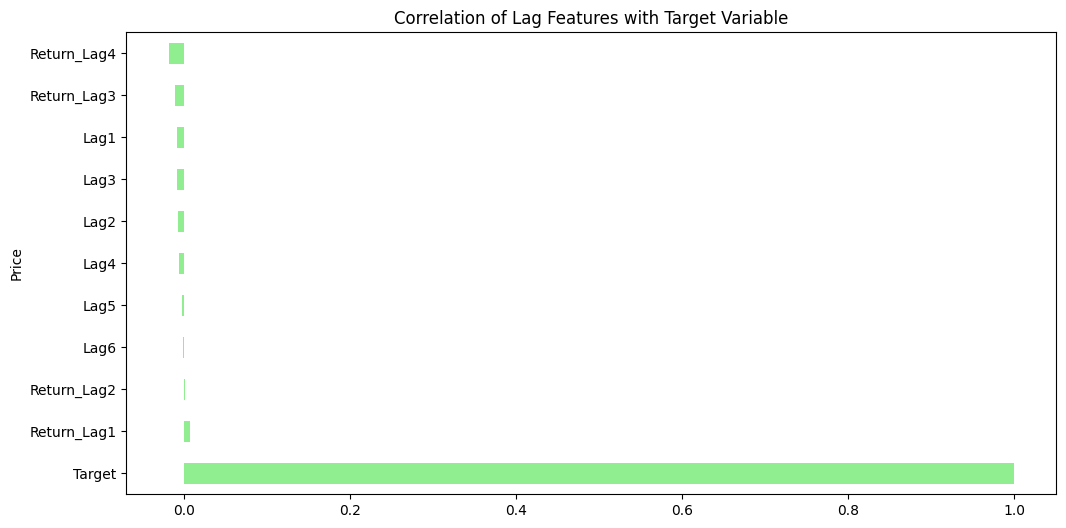

In [182]:
# Check feature correations with the target variable
corr_with_target = stocks.corr()['Target'].sort_values(ascending=False)
print("Correlation of features with Target variable:")
print(corr_with_target)
stocks.corr()
#corr_with_target.plot(kind='barh', title='Correlation of Features with Target Variable', figsize=(12, 10), color='skyblue')
fig = px.imshow(stocks.corr(), title='Correlation Heatmap of Stock Features', width=1000, height=800)
fig.show()

corr_with_close = stocks.corr()['Close'].sort_values(ascending=False).drop('Close')
print("Correlation of features with Close price:")
print(corr_with_close)
#corr_with_close.plot(kind='barh', title='Correlation of Features with Close Price', figsize=(12, 6), color='salmon')
#fig.show()

# Correlation of lag features with the target variable
lag_features = [col for col in stocks.columns if 'Lag' in col]
corr_with_lags = stocks[lag_features + ['Target']].corr()['Target'].sort_values(ascending=False)
corr_with_lags.plot(kind='barh', title='Correlation of Lag Features with Target Variable', figsize=(12, 6), color='lightgreen')

In [188]:


# Scatter plot of momentum indicators vs stock target
#fig = px.scatter(stocks, x='RSI', y='Target', title='Momentum Indicator vs Stock Target', width=1000, height=600)
#fig.show()

#import seaborn as sns
#sns.boxplot(x=stocks['Target'], y=stocks['RSI'])


(stocks['RSI'] > 70).groupby(stocks['Target']).mean()
#(stocks['RSI'] < 30).groupby(stocks['Target']).mean()

Target
0    0.207921
1    0.183521
Name: RSI, dtype: float64

In [ ]:
# Drop rows with NaN values resulting from rolling calculations
stocks.dropna(inplace=True)

def drop_columns_and_reset_index(df, columns_to_drop):
    df.drop(columns=columns_to_drop, inplace=True)
    df.reset_index(inplace=True)
    return df
# Remove the date column as it won't be used for modeling
#stocks.reset_index(inplace=True)
# Remove the features that won't be used for modeling
#stocks = drop_columns_and_reset_index(stocks, ['Date', 'EMA12', 'EMA26', 'STD20', 'SignalLine'])
#stocks.drop(columns=['price'], inplace=True)

stocks.head()

Price,Close,Volume,sp500,nasdaq,dowjones,Gold,Bitcoin,Target,MA20,STD20,...,VolumeSpike,RSI,EMA12,EMA26,MACD,SignalLine,MACD_Histogram,DayOfWeek,Month,Quarter
Date,,,,,,,,,,,,,,,,,,,,,
2020-10-15,77.135963,31210000,3483.340088,11713.870117,28494.199219,1.248409,1.596538,1,73.352690,2.407330,...,0,71.664062,75.270604,74.828116,0.442488,-0.310633,0.753122,3,10,4
2020-10-16,77.742455,34194000,3483.810059,11671.559570,28606.310547,1.246835,1.572479,1,73.641825,2.572806,...,0,70.864863,75.650889,75.043993,0.606896,-0.127127,0.734023,4,10,4
2020-10-19,75.870438,29734000,3426.919922,11478.879883,28195.419922,1.250508,1.630799,1,73.889305,2.535073,...,0,60.958549,75.684666,75.105211,0.579455,0.014189,0.565266,0,10,4
2020-10-20,76.918274,41670000,3443.120117,11516.490234,28308.789062,1.253132,1.655006,1,74.115585,2.595705,...,0,63.681201,75.874452,75.239512,0.634940,0.138339,0.496600,1,10,4
2020-10-21,78.649467,60322000,3435.560059,11484.690430,28210.820312,1.262447,1.781025,0,74.553466,2.584338,...,1,65.090354,76.301377,75.492101,0.809276,0.272526,0.536749,2,10,4


# Modeling - using Logistical Regression

In [ ]:
# Test train split

def test_train_split_local(df, target_col='Target', test_size=0.2):
    X = df.drop(columns=[target_col, 'Date'])
    y = df[target_col]
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, shuffle=False)
    return X_train, X_test, y_train, y_test


def run_logistic_regression(stocks):
    from sklearn.linear_model import LogisticRegression
    lr = LogisticRegression(max_iter=1000, random_state=42)
    X_train, X_test, y_train, y_test = test_train_split_local(stocks, target_col='Target', test_size=0.2)
    lr.fit(X_train, y_train)

    score = lr.score(X_test, y_test)

    print(f"Logistic Regression Accuracy: {score:.2f}")


## Using other classification models like RandomForest, KNN

In [ ]:
def run_random_forest(stocks):
    from sklearn.ensemble import RandomForestClassifier
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    X_train, X_test, y_train, y_test = test_train_split_local(stocks, target_col='Target', test_size=0.2)

    rf.fit(X_train, y_train)    

    score = rf.score(X_test, y_test)
    print(f"Random Forest Accuracy: {score:.2f}")

In [ ]:
# KNN
def run_knn(stocks):
    from sklearn.neighbors import KNeighborsClassifier
    knn = KNeighborsClassifier(n_neighbors=5)
    X_train, X_test, y_train, y_test = test_train_split_local(stocks, target_col='Target', test_size=0.2)

    knn.fit(X_train, y_train)

    score = knn.score(X_test, y_test)
    print(f"KNN Accuracy: {score:.2f}")


### Choose the Model hyperparameters using GridSearchCV

In [ ]:

from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1],
    'fit_intercept': [True, False]
}

grid_search = GridSearchCV(lr, param_grid)
grid_search.fit(X_train, y_train)
print(f"Best Hyperparameters: {grid_search.best_params_}")

NameError: name 'lr' is not defined

### Using models with updated parameters

In [ ]:
def run_tuned_logistic_regression(stocks, grid_search):
    X_train, X_test, y_train, y_test = test_train_split_local(stocks, target_col='Target', test_size=0.2)

    lr_tuned = LogisticRegression(C=grid_search.best_params_['C'], 
        fit_intercept=grid_search.best_params_['fit_intercept'], max_iter=1000, random_state=42)
    lr_tuned.fit(X_train, y_train)
    score = lr_tuned.score(X_test, y_test)
    print(f"Tuned Logistic Regression Accuracy: {score:.2f}")

In [ ]:
stocks.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 42 columns):
 #   Column          Non-Null Count  Dtype        
---  ------          --------------  -----        
 0   Date            1309 non-null   datetime64[s]
 1   Close           1309 non-null   float64      
 2   Volume          1309 non-null   int64        
 3   sp500           1309 non-null   float64      
 4   nasdaq          1309 non-null   float64      
 5   dowjones        1309 non-null   float64      
 6   Gold            1309 non-null   float64      
 7   Bitcoin         1309 non-null   float64      
 8   Target          1309 non-null   int64        
 9   MA20            1309 non-null   float64      
 10  STD20           1309 non-null   float64      
 11  UpperBand       1309 non-null   float64      
 12  LowerBand       1309 non-null   float64      
 13  Return          1309 non-null   float64      
 14  Momentum_5      1309 non-null   float64      
 15  ROC_5           1309 non-null   

In [ ]:
# Remove more features and see if it improves accuracy
#stocks.drop(columns=['index', 'sp500', 'VolumeSpike'], inplace=True)
stocks_cpy = stocks.copy()
stocks_cpy = drop_columns_and_reset_index(stocks_cpy, ['EMA12', 'EMA26', 'STD20', 'SignalLine', 'Return_Lag1', 'Return_Lag2'])
stocks_cpy.info()


<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 37 columns):
 #   Column          Non-Null Count  Dtype        
---  ------          --------------  -----        
 0   index           1309 non-null   int64        
 1   Date            1309 non-null   datetime64[s]
 2   Close           1309 non-null   float64      
 3   Volume          1309 non-null   int64        
 4   sp500           1309 non-null   float64      
 5   nasdaq          1309 non-null   float64      
 6   dowjones        1309 non-null   float64      
 7   Gold            1309 non-null   float64      
 8   Bitcoin         1309 non-null   float64      
 9   Target          1309 non-null   int64        
 10  MA20            1309 non-null   float64      
 11  UpperBand       1309 non-null   float64      
 12  LowerBand       1309 non-null   float64      
 13  Return          1309 non-null   float64      
 14  Momentum_5      1309 non-null   float64      
 15  ROC_5           1309 non-null   

In [ ]:
# Using XG boost
def run_xgboost(stocks):
    from xgboost import XGBClassifier
    xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    xgb.fit(X_train, y_train)   
    score = xgb.score(X_test, y_test)
    print(f"XGBoost Accuracy: {score:.2f}")

### Check the importance of different features

In [ ]:
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = test_train_split_local(stocks_cpy, target_col='Target', test_size=0.2)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print('Random Forest Accuracy: {:.2f}'.format(rf.score(X_test, y_test)))

# print the name of the feature along with its importance
for feature, importance in zip(X_train.columns, rf.feature_importances_):
    print(f'{feature}: {importance:.4f}')

Random Forest Accuracy: 0.52
index: 0.0264
Close: 0.0293
Volume: 0.0375
sp500: 0.0296
nasdaq: 0.0278
dowjones: 0.0300
Gold: 0.0360
Bitcoin: 0.0269
MA20: 0.0237
UpperBand: 0.0264
LowerBand: 0.0253
Return: 0.0417
Momentum_5: 0.0367
ROC_5: 0.0356
Return_Lag3: 0.0379
Return_Lag4: 0.0405
MA5: 0.0240
MA50: 0.0252
MA200: 0.0280
Price_vs_MA20: 0.0372
Lag1: 0.0269
Lag2: 0.0282
Lag3: 0.0257
Lag4: 0.0225
Lag5: 0.0245
Lag6: 0.0289
Volume_MA5: 0.0444
Volatility: 0.0327
VolumeSpike: 0.0024
RSI: 0.0373
MACD: 0.0330
MACD_Histogram: 0.0342
DayOfWeek: 0.0172
Month: 0.0114
Quarter: 0.0050


In [ ]:
def AddFEDFeatures(stocks, start_date, end_date):
    # Use the FED data to get the following features:
    # - Federal Funds Rate
    # - Inflation Rate
    # - Unemployment Rate
    %pip install fredapi
    from fredapi import Fred
    fred = Fred(api_key='c06a7676bffb4c8338823496ee6287bf')

    interest_rate = fred.get_series('FEDFUNDS', observation_start=start_date, observation_end=end_date)
    inflation_rate = fred.get_series('CPIAUCSL', observation_start=start_date, observation_end=end_date)
    unemployment_rate = fred.get_series('UNRATE', observation_start=start_date, observation_end=end_date)

    print(interest_rate.head())

    stocks['FederalFundsRate'] = interest_rate
    stocks['InflationRate'] = inflation_rate
    stocks['UnemploymentRate'] = unemployment_rate

